### Prof. Alfio Ferrara

# Dal documento al dato

##  Metodologie informatiche nelle discipline umanistiche
##### A.A. 2026/2027

---

Immaginiamo di avere davanti una pagina di carta, stampata più di cento anni fa. Contiene informazioni preziose per chi studia la storia, la lingua, la politica di un'epoca. Ma un programma non può "leggere" una pagina di carta: può solo leggere dati.

Come si passa dall'una all'altro?

In [1]:
%load_ext autoreload
%autoreload 2

## Prima esperienza: da una pagina scannerizzata al testo

La pagina che vediamo è la prima di un documento storico reale: il resoconto della seduta del Parlamento italiano del 1° dicembre 1919, giorno di inaugurazione della XXV legislatura, con il discorso della Corona.

Il file di partenza è un PDF ottenuto scannerizzando gli atti parlamentari originali: dal punto di vista del computer, per ora, è solo un'immagine.

Proviamo a farla "leggere" a un programma di riconoscimento ottico dei caratteri (OCR), che tenta di trasformare i pixel dell'immagine in caratteri e parole.

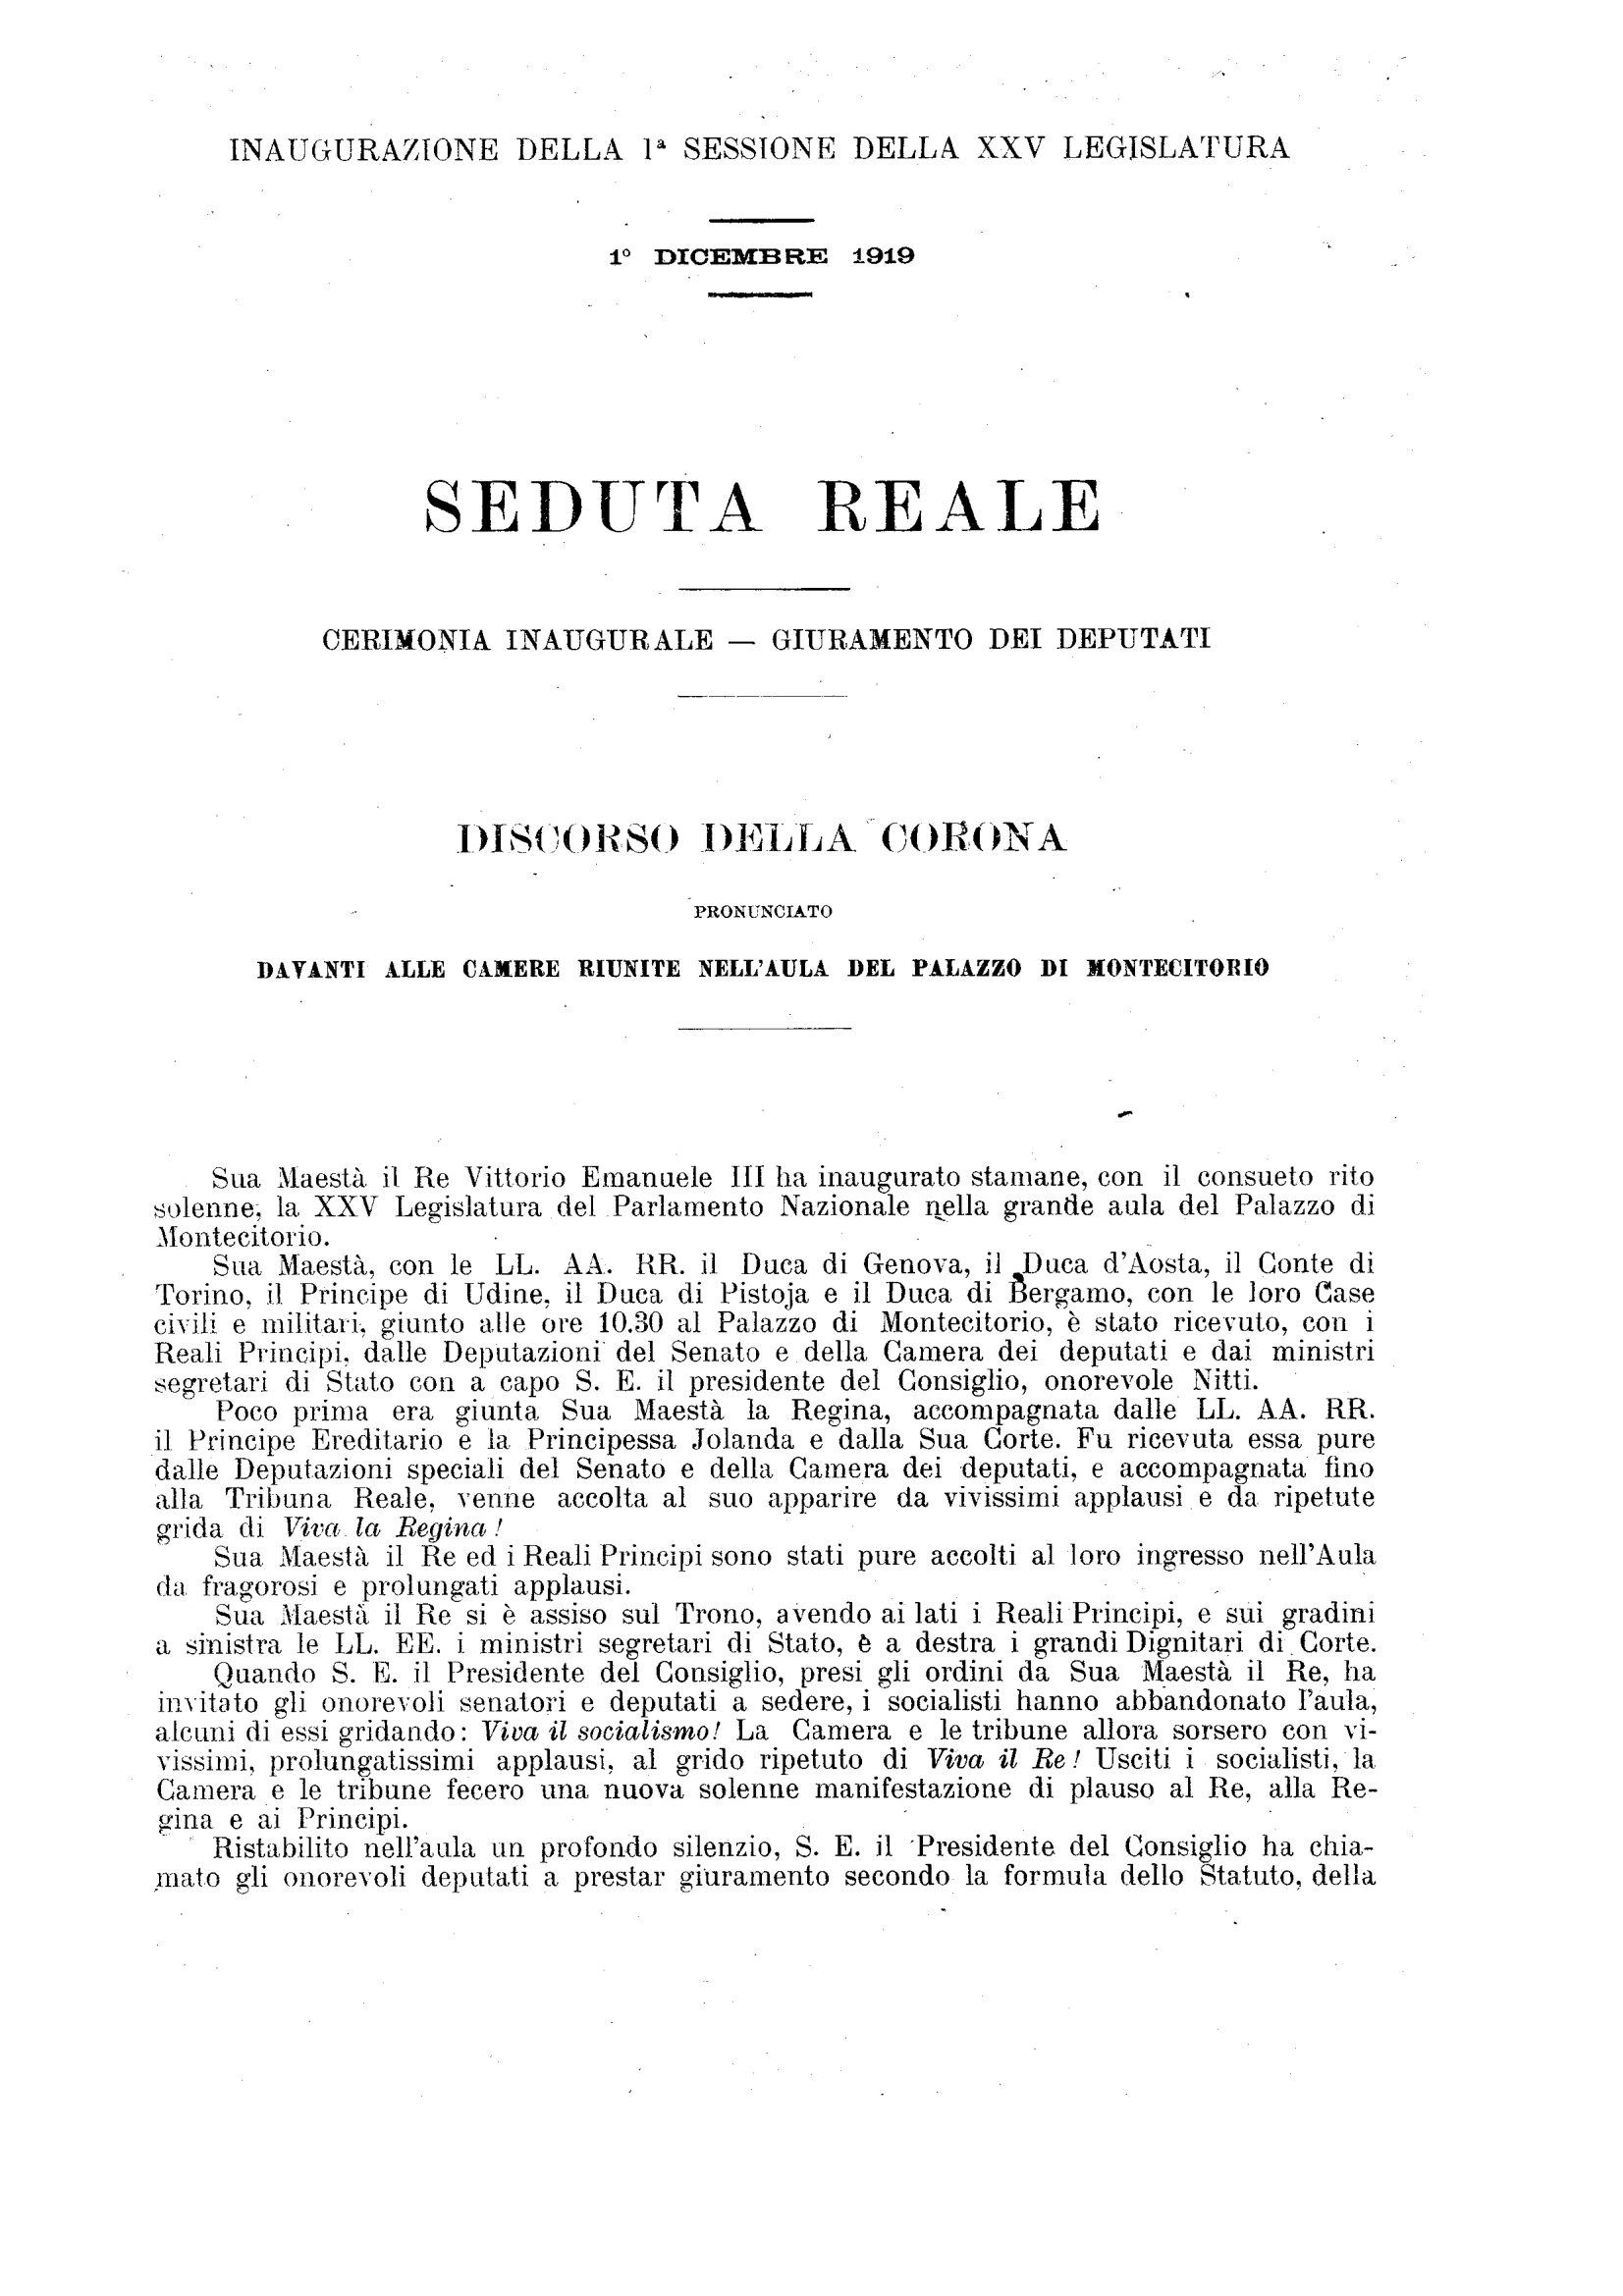

In [2]:
from nlp.documents import render_pdf_page, ocr_page, load_transcription

page_image = render_pdf_page("data/seduta_1919-12-01.pdf", page_number=0)
page_image

In [3]:
ocr_text = ocr_page(page_image)
print(ocr_text)

INAUGURAZIONE DELLA 1* SESSIONE DELLA XXV LEGISLATURA

1° DICEMBRE 1919

SEDUTA REALE

CERIMONIA INAUGURALE — GIURAMENTO DEI DEPUTATI

DISCORSO DELLA CORONA

DAYANTI ALLE CAMERE RIUNITE NELL’AULA DEL PALAZZO DI MONTECITORIO

P

Sua Maestà il Re Vittorio Emanuele III ha inaugurato stamane, con il consueto rito
solenne, la XXV Legis]atura del Parlamento Nazionale nella grande aula del Palazzo di
Montecitorio.

Sua Maestà, con le LL AA. RR. il Duca di Genova, il Duca d’Aosta, il Conte di
Torino, il Principe di Udine, il Duea di Pistoja e il Duca di Bergamo, con le loro Gase
civili e militari, giunto alle ore 10.30 al Palazzo di Montecitorio, è stato ricevuto, con ì
Reali Principi, dalle Deputazioni del Senato e della Camera dei deputati e dai ministri
segretari di Stato con a capo S. E. il presidente del CGonsiglio, onorevole Nitti.

Poco prima era giunta Sua Maestà la Regina, accompagnata dalle LL. AA. RR.
il Principe Ereditario e la Principessa Jolanda e ‘dalla Sua Corte. Fu ricevuta es

Sia la pagina scannerizzata sia il testo appena ottenuto sono, per il computer, soltanto sequenze di byte — esattamente come abbiamo visto nella lezione precedente per le immagini e per il testo. Diamo un'occhiata diretta a un piccolo frammento di entrambe le rappresentazioni: i primi byte del file PDF, e i byte del testo prodotto dall'OCR.

In [4]:
from nlp.documents import read_bytes, show_bytes

pdf_bytes = read_bytes("data/seduta_1919-12-01.pdf", n=32)
show_bytes(pdf_bytes)

b'%PDF-1.4\n%\xe2\xe3\xcf\xd3\n2 0 obj\n<</Length'
00100101 01010000 01000100 01000110 00101101 00110001 00101110 00110100 00001010 00100101 11100010 11100011 11001111 11010011 00001010 00110010 00100000 00110000 00100000 01101111 01100010 01101010 00001010 00111100 00111100 00101111 01001100 01100101 01101110 01100111 01110100 01101000


In [5]:
text_bytes = ocr_text[:20].encode("utf-8")
show_bytes(text_bytes)

b'INAUGURAZIONE DELLA '
01001001 01001110 01000001 01010101 01000111 01010101 01010010 01000001 01011010 01001001 01001111 01001110 01000101 00100000 01000100 01000101 01001100 01001100 01000001 00100000


Il testo che abbiamo ottenuto non è ancora un "dato" nel senso pieno del termine: è una sequenza di caratteri prodotta automaticamente, con tutti i limiti del riconoscimento ottico.

Confrontiamolo ora con la trascrizione della stessa pagina già presente in un corpus di atti parlamentari, curata e corretta da chi l'ha preparata.

In [6]:
clean_text = load_transcription(
    "/Users/Flint/Data/parlamento/Dati Parlamento/19191201_sr25000A_00.json",
    page_number=1,
    types=("page-header", "section-header", "text"),
)
print(clean_text)

INAUGURAZIONE DELLA 1ª SESSIONE DELLA XXV LEGISLATURA

1° DICEMBRE 1919

SEDUTA REALE

CERIMONIA INAUGURALE — GIURAMENTO DEI DEPUTATI

DISCORSO DELLA CORONA

PRONUNCIATO

DAVANTI ALLE CAMERE RIUNITE NELL'AULA DEL PALAZZO DI MONTECITORIO

Sua Maestà il Re Vittorio Emanuele III ha inaugurato stamane, con il consueto rito solenne, la XXV Legislatura del Parlamento Nazionale nella grande aula del Palazzo di Montecitorio.

Sua Maestà, con le LL. AA. RR. il Duca di Genova, il Duca d'Aosta, il Conte di Torino, il Principe di Udine, il Duca di Pistoja e il Duca di Bergamo, con le loro Case civili e militari, giunto alle ore 10.30 al Palazzo di Montecitorio, è stato ricevuto, con i Reali Principi, dalle Deputazioni del Senato e della Camera dei deputati e dai ministri segretari di Stato con a capo S. E. il presidente del Consiglio, onorevole Nitti.

Poco prima era giunta Sua Maestà la Regina, accompagnata dalle LL. AA. RR. il Principe Ereditario e la Principessa Jolanda e dalla Sua Corte. Fu ri

## Un momento di riflessione

- Quali differenze noti tra il testo prodotto dall'OCR e la trascrizione corretta? Sono errori casuali o seguono un pattern?
- La pagina scannerizzata, il testo OCR e la trascrizione corretta sono tre modi diversi di rappresentare "la stessa cosa". In che senso lo sono? In che senso non lo sono più?
- In quale di queste tre forme il contenuto è già utilizzabile da un programma per, ad esempio, contare quante volte compare una parola? E in quali no, o solo in parte?
- Chi (o cosa) ha dovuto intervenire per passare dal testo OCR alla trascrizione corretta? Che tipo di lavoro è stato?
- Possiamo dire che il documento di carta "contiene" già il dato, oppure il dato è qualcosa che va costruito a partire dal documento?
- A livello di byte, cosa hanno in comune il frammento di PDF e il frammento di testo? Cosa li distingue?
- Se apri il file PDF con un editor di testo qualsiasi, invece che con un lettore di PDF, cosa vedresti, e perché?
- Possiamo descrivere l'OCR come un procedimento che trasforma una sequenza di byte in un'altra sequenza di byte? Che cosa "sa fare in più", rispetto a un semplice cambio di codifica come quello visto tra Latin-1 e UTF-8?

## Seconda esperienza: dato e informazione sul dato

Torniamo al file JSON con la trascrizione pulita della seduta. Finora abbiamo guardato solo il testo estratto da `content`. Ma il file contiene, per ogni frammento, anche altre informazioni. Guardiamole da vicino, insieme a quello che il file PDF stesso porta con sé.

In [7]:
from nlp.documents import load_entries

entries = load_entries("/Users/Flint/Data/parlamento/Dati Parlamento/19191201_sr25000A_00.json")

for entry in entries[:5]:
    print(entry)

{'speaker': 'none', 'type': 'page-header', 'content': 'INAUGURAZIONE DELLA 1ª SESSIONE DELLA XXV LEGISLATURA', 'page_number_in_pdf': 1, 'speaker_uri': ['none']}
{'speaker': 'none', 'type': 'page-header', 'content': '1° DICEMBRE 1919', 'page_number_in_pdf': 1, 'speaker_uri': ['none']}
{'speaker': 'none', 'type': 'section-header', 'content': 'SEDUTA REALE', 'page_number_in_pdf': 1, 'speaker_uri': ['none']}
{'speaker': 'none', 'type': 'section-header', 'content': 'CERIMONIA INAUGURALE — GIURAMENTO DEI DEPUTATI', 'page_number_in_pdf': 1, 'speaker_uri': ['none']}
{'speaker': 'none', 'type': 'section-header', 'content': 'DISCORSO DELLA CORONA', 'page_number_in_pdf': 1, 'speaker_uri': ['none']}


Scorrendo il file, il valore del campo `speaker` cambia a un certo punto.

In [8]:
for entry in entries:
    if entry["speaker"] not in ("none", "unknown"):
        print(entry)
        break

{'speaker': 'SUA MAESTÀ IL RE', 'type': 'text', 'content': 'SIGNORI SENATORI, SIGNORI DEPUTATI!', 'page_number_in_pdf': 2, 'speaker_uri': ['none']}


Anche il file PDF di partenza, indipendentemente dal suo contenuto, porta con sé alcune informazioni.

In [9]:
import pymupdf

doc = pymupdf.open("data/seduta_1919-12-01.pdf")
doc.metadata

{'format': 'PDF 1.4',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': '',
 'producer': 'iText® 5.3.4 ©2000-2012 1T3XT BVBA (AGPL-version)',
 'creationDate': "D:20140114213615+01'00'",
 'modDate': "D:20140114213615+01'00'",
 'trapped': '',
 'encryption': None}

## Un momento di riflessione

- Nel file JSON, cosa consideri "il contenuto" e cosa consideri "informazione sul contenuto"? Dove tracceresti il confine?
- Il campo `speaker` passa da `"none"`/`"unknown"` a `"SUA MAESTÀ IL RE"` in un punto preciso del documento. Cosa segnala questo cambiamento? A cosa potrebbe servire, in futuro, sapere questo per ogni frammento?
- Guarda `creationDate` nei metadati del PDF: 2014. Ma la seduta di cui parla è del 1919. Come si spiega questa differenza? Di che cosa è data quella data?
- Uno stesso elemento, per esempio "pagina 2", può essere sia dato sia informazione-sul-dato, a seconda di cosa stiamo osservando? Prova a fare un esempio con gli elementi che hai visto.
- Se dovessi cercare, in un archivio di migliaia di sedute parlamentari, tutti gli interventi di un certo oratore, quali di queste informazioni ti servirebbero? Il solo testo sarebbe sufficiente?

## Terza esperienza: interrogare un servizio e leggere una struttura esplicita

Finora abbiamo lavorato con testo e con un file JSON già pronto. Ma spesso i dati non li troviamo già pronti su un disco: li chiediamo a un servizio, tramite internet, e il servizio ce li restituisce in un formato con una propria struttura dichiarata.

Proviamo a chiedere informazioni sulla voce di Wikipedia dedicata a Guglielmo Marconi, tramite l'API pubblica di Wikipedia, chiedendo la risposta in formato XML.

In [10]:
import requests

url = "https://it.wikipedia.org/w/api.php"
params = {
    "action": "query",
    "titles": "Guglielmo Marconi",
    "prop": "info|categories",
    "format": "xml",
}
headers = {"User-Agent": "corso-MIDH/1.0 (uso didattico)"}

response = requests.get(url, params=params, headers=headers)
print(response.url)
print(response.status_code)

https://it.wikipedia.org/w/api.php?action=query&titles=Guglielmo+Marconi&prop=info%7Ccategories&format=xml
200


Prima di guardare la risposta nella cella qui sotto, apri questo indirizzo in una scheda del browser: la struttura ad albero risulta molto più leggibile lì che nell'output grezzo del notebook.

<https://it.wikipedia.org/w/api.php?action=query&titles=Guglielmo%20Marconi&prop=info%7Ccategories&format=xml>

In [11]:
print(response.text)

<?xml version="1.0"?><api><continue clcontinue="2691964|Croci_al_merito_di_guerra" continue="||info" /><query><pages><page _idx="2691964" pageid="2691964" ns="0" title="Guglielmo Marconi" contentmodel="wikitext" pagelanguage="it" pagelanguagehtmlcode="it" pagelanguagedir="ltr" touched="2026-09-22T12:48:54Z" lastrevid="151716359" length="71015"><categories><cl ns="14" title="Categoria:Accademici dei Lincei" /><cl ns="14" title="Categoria:Accademici dell&#039;Accademia d&#039;Italia" /><cl ns="14" title="Categoria:BioBot" /><cl ns="14" title="Categoria:Cavalieri del lavoro" /><cl ns="14" title="Categoria:Cavalieri dell&#039;Ordine civile di Savoia" /><cl ns="14" title="Categoria:Cavalieri dell&#039;Ordine di Sant&#039;Anna" /><cl ns="14" title="Categoria:Cavalieri di Gran Croce dell&#039;Ordine Piano" /><cl ns="14" title="Categoria:Cavalieri di Gran Croce dell&#039;Ordine del Principe Danilo I" /><cl ns="14" title="Categoria:Cavalieri di Gran Croce dell&#039;Ordine reale vittoriano" /><c

Ora proviamo a farci restituire da Python, non solo il testo grezzo, ma alcuni valori precisi, sfruttando il fatto che la struttura è dichiarata esplicitamente da tag annidati e attributi.

In [12]:
import xml.etree.ElementTree as ET

root = ET.fromstring(response.text)
page = root.find(".//page")

print("titolo:", page.attrib["title"])
print("pageid:", page.attrib["pageid"])
print("ultima modifica:", page.attrib["touched"])
print("lunghezza in byte:", page.attrib["length"])

titolo: Guglielmo Marconi
pageid: 2691964
ultima modifica: 2026-09-22T12:48:54Z
lunghezza in byte: 71015


In [13]:
categories = page.find("categories")

for category in list(categories)[:10]:
    print(category.tag, category.attrib)

cl {'ns': '14', 'title': 'Categoria:Accademici dei Lincei'}
cl {'ns': '14', 'title': "Categoria:Accademici dell'Accademia d'Italia"}
cl {'ns': '14', 'title': 'Categoria:BioBot'}
cl {'ns': '14', 'title': 'Categoria:Cavalieri del lavoro'}
cl {'ns': '14', 'title': "Categoria:Cavalieri dell'Ordine civile di Savoia"}
cl {'ns': '14', 'title': "Categoria:Cavalieri dell'Ordine di Sant'Anna"}
cl {'ns': '14', 'title': "Categoria:Cavalieri di Gran Croce dell'Ordine Piano"}
cl {'ns': '14', 'title': "Categoria:Cavalieri di Gran Croce dell'Ordine del Principe Danilo I"}
cl {'ns': '14', 'title': "Categoria:Cavalieri di Gran Croce dell'Ordine reale vittoriano"}
cl {'ns': '14', 'title': "Categoria:Cavalieri di gran croce dell'Ordine della Corona d'Italia"}


## Un momento di riflessione

- Confronta la risposta XML con il file JSON della seduta parlamentare: cosa hanno in comune, come modo di organizzare i dati? Cosa cambia nella sintassi?
- Qui quasi tutte le informazioni (titolo, data di modifica, lunghezza, categorie) sono attributi di tag, non testo contenuto in un tag. Che differenza fa, dal punto di vista di chi legge questi dati con un programma?
- La struttura (i nomi dei tag e degli attributi, l'annidamento) è stata dichiarata da chi ha creato il servizio, non inventata da noi. Perché è importante che sia così, se migliaia di programmi diversi devono leggere questi dati?
- Per fare la richiesta abbiamo dovuto dichiarare uno "User-Agent", cioè presentarci come programma. Che differenza c'è tra questo e una vera autenticazione con credenziali?
- Che cosa succederebbe se provassi a chiedere la stessa voce a un altro sito, che non usa XML ma un proprio formato tutto testuale? I dati sarebbero ancora "gli stessi"?

## Quarta esperienza: interrogare una base di dati con una domanda formale

Torniamo alla Camera dei deputati, la stessa istituzione della seduta del 1919 da cui siamo partiti. Oggi la Camera pubblica una parte dei propri dati come *open data* interrogabili: non un singolo file da scaricare, ma una base di dati a cui si possono porre domande dirette, scritte in un linguaggio di interrogazione (SPARQL), ottenendo come risposta JSON.

Proviamo a chiedere: chi sono alcuni dei deputati dell'attuale legislatura?

In [14]:
import requests

query = """
PREFIX ocd: <http://dati.camera.it/ocd/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT DISTINCT ?deputato ?label WHERE {
  ?deputato a ocd:deputato .
  ?deputato ocd:rif_leg <http://dati.camera.it/ocd/legislatura.rdf/repubblica_19> .
  ?deputato rdfs:label ?label .
} LIMIT 8
"""

response = requests.get(
    "https://dati.camera.it/sparql",
    params={"query": query, "format": "application/sparql-results+json"},
)
print(response.url)
print(response.status_code)

https://dati.camera.it/sparql?query=%0APREFIX+ocd%3A+%3Chttp%3A%2F%2Fdati.camera.it%2Focd%2F%3E%0APREFIX+rdfs%3A+%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0ASELECT+DISTINCT+%3Fdeputato+%3Flabel+WHERE+%7B%0A++%3Fdeputato+a+ocd%3Adeputato+.%0A++%3Fdeputato+ocd%3Arif_leg+%3Chttp%3A%2F%2Fdati.camera.it%2Focd%2Flegislatura.rdf%2Frepubblica_19%3E+.%0A++%3Fdeputato+rdfs%3Alabel+%3Flabel+.%0A%7D+LIMIT+8%0A&format=application%2Fsparql-results%2Bjson
200


Anche qui, apri l'indirizzo stampato sopra in una scheda del browser: molti browser mostrano il JSON con una struttura ad albero navigabile, più leggibile del testo grezzo.

In [15]:
import json

data = response.json()
print(json.dumps(data, indent=2, ensure_ascii=False))

{
  "head": {
    "link": [],
    "vars": [
      "deputato",
      "label"
    ]
  },
  "results": {
    "distinct": false,
    "ordered": true,
    "bindings": [
      {
        "deputato": {
          "type": "uri",
          "value": "http://dati.camera.it/ocd/deputato.rdf/d309220_19"
        },
        "label": {
          "type": "typed-literal",
          "datatype": "http://www.w3.org/2001/XMLSchema#string",
          "value": "ALBERTO PANDOLFO, XIX Legislatura della Repubblica"
        }
      },
      {
        "deputato": {
          "type": "uri",
          "value": "http://dati.camera.it/ocd/deputato.rdf/d301531_19"
        },
        "label": {
          "type": "typed-literal",
          "datatype": "http://www.w3.org/2001/XMLSchema#string",
          "value": "MARIA ROSARIA CARFAGNA, XIX Legislatura della Repubblica"
        }
      },
      {
        "deputato": {
          "type": "uri",
          "value": "http://dati.camera.it/ocd/deputato.rdf/d306064_19"
        },

Da questa struttura possiamo estrarre solo ciò che ci interessa, per esempio i soli nomi.

In [16]:
nomi = [binding["label"]["value"] for binding in data["results"]["bindings"]]
nomi

['ALBERTO PANDOLFO, XIX Legislatura della Repubblica',
 'MARIA ROSARIA CARFAGNA, XIX Legislatura della Repubblica',
 'GIULIO CESARE SOTTANELLI, XIX Legislatura della Repubblica',
 'CHIARA APPENDINO, XIX Legislatura della Repubblica',
 'PAOLO PULCIANI, XIX Legislatura della Repubblica',
 'PAOLA FRASSINETTI, XIX Legislatura della Repubblica',
 'ANDREA CAROPPO, XIX Legislatura della Repubblica',
 'VITTORIA BALDINO, XIX Legislatura della Repubblica']

## Un momento di riflessione

- In ogni "binding" del risultato, ogni valore è accompagnato da un campo `type` (e a volte `datatype`). A cosa servono questi campi, rispetto al valore vero e proprio? Richiama quanto discusso a proposito di dato e informazione sul dato.
- Il deputato è identificato da un indirizzo (`http://dati.camera.it/ocd/deputato.rdf/...`), non solo dal nome. Perché una base di dati preferisce identificare le cose così, invece che con il nome per esteso?
- Per ottenere questi dati abbiamo scritto una piccola query, cioè una domanda formale in un linguaggio apposito (SPARQL), invece di limitarci a indicare un indirizzo con dei parametri come nell'esempio precedente. Che tipo di libertà in più (e di complessità in più) comporta?
- Confronta questa struttura JSON con il file JSON della seduta parlamentare visto a inizio lezione, e con l'XML di Wikipedia. Cosa hanno in comune tutti e tre come modo di rappresentare l'informazione? Cosa li distingue?
- Nel 1919 il resoconto della seduta era un documento di carta, che oggi dobbiamo ricostruire con l'OCR. I dati sui deputati di oggi sono già nati come dati interrogabili. Cosa cambia, per chi farà ricerca storica fra cent'anni, tra questi due modi di produrre e conservare l'informazione istituzionale?

## Quinta esperienza: tre modi diversi di rappresentare la stessa cosa

Restiamo su Guglielmo Marconi, ma guardiamo la stessa informazione — chi era, quando è nato, cosa ha fatto — così come esiste in tre punti diversi dell'ecosistema Wikipedia: il testo che si legge nella pagina, il codice sorgente con cui quella pagina è scritta, e la scheda collegata su Wikidata, il database di fatti che sta dietro Wikipedia.

In [17]:
import requests

headers = {"User-Agent": "corso-MIDH/1.0 (uso didattico)"}

response = requests.get(
    "https://it.wikipedia.org/w/api.php",
    params={
        "action": "query",
        "titles": "Guglielmo Marconi",
        "prop": "extracts",
        "exintro": 1,
        "explaintext": 1,
        "format": "json",
    },
    headers=headers,
)
page = next(iter(response.json()["query"]["pages"].values()))
print(page["extract"][:500])

Guglielmo Giovanni Maria Marconi (Bologna, 25 aprile 1874 – Roma, 20 luglio 1937) è stato un inventore, imprenditore e politico italiano.
È considerato uno dei principali protagonisti dello sviluppo delle telecomunicazioni moderne per il suo contributo alla realizzazione e alla diffusione della telegrafia senza fili, un sistema di comunicazione a distanza basato sulle onde radio. Il suo lavoro contribuì allo sviluppo dei sistemi di radiocomunicazione e gli valse il premio Nobel per la fisica nel


Questo è il testo così come lo legge una persona: prosa continua, senza alcuna struttura dichiarata. Guardiamo ora il codice sorgente della stessa pagina, quello che chi scrive su Wikipedia effettivamente modifica.

In [18]:
response = requests.get(
    "https://it.wikipedia.org/w/api.php",
    params={
        "action": "query",
        "titles": "Guglielmo Marconi",
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "format": "json",
    },
    headers=headers,
)
page = next(iter(response.json()["query"]["pages"].values()))
wikitext = page["revisions"][0]["slots"]["main"]["*"]
print(wikitext[:900])

{{nota disambigua||Marconi (disambigua)|titolo2=Guglielmo Marconi (disambigua)|Marconi}}
{{Carica pubblica
|nome = Guglielmo Marconi
|immagine = Guglielmo Marconi.jpg
|didascalia = Guglielmo Marconi nel [[1908]]
|carica = [[Senato del Regno (Italia)|Senatore del Regno d'Italia]]
|mandatoinizio = 30 aprile [[1914]]
|mandatofine = 20 luglio [[1937]]
|legislatura = 
|gruppo parlamentare = 
|coalizione = 
|circoscrizione = 
|collegio = 
|tipo nomina = {{Categoria Senatori|20}}
|incarichi = 
|sito = {{Senatori Regno}}
|partito = [[Partito Nazionale Fascista]]
|alma mater = 
|professione = scienziato, imprenditore
|firma = Guglielmo Marconi Signature.svg
}}
{{Aristocratico
|nome = Guglielmo Giovanni Maria Marconi
|immagine = 
|legenda = 
|stemma = stemma_marconi.png
|titolo = Marchese Marconi
|investitura = R.D. 17 giugno [[1929]]
|data di nascita = 25 aprile [[1874]]
|data di morte = {{Calcol


Il testo della pagina contiene, mescolati alla prosa, dei template con parametri nominati (come `{{Bio| ... }}`): non è testo libero, ma non è nemmeno un formato dati vero e proprio.

Infine, guardiamo la scheda della stessa persona su Wikidata, dove ogni fatto è una singola affermazione tipata, senza testo intorno.

In [19]:
response = requests.get(
    "https://www.wikidata.org/w/api.php",
    params={
        "action": "wbgetentities",
        "sites": "itwiki",
        "titles": "Guglielmo Marconi",
        "props": "claims",
        "format": "json",
    },
    headers=headers,
)
claims = list(response.json()["entities"].values())[0]["claims"]

def valore(proprieta):
    return claims[proprieta][0]["mainsnak"]["datavalue"]["value"]

print("P569 (data di nascita):", valore("P569"))
print("P19  (luogo di nascita):", valore("P19"))
print("P106 (occupazione):", valore("P106"))

P569 (data di nascita): {'time': '+1874-04-25T00:00:00Z', 'timezone': 0, 'before': 0, 'after': 0, 'precision': 11, 'calendarmodel': 'http://www.wikidata.org/entity/Q1985727'}
P19  (luogo di nascita): {'entity-type': 'item', 'numeric-id': 1891, 'id': 'Q1891'}
P106 (occupazione): {'entity-type': 'item', 'numeric-id': 169470, 'id': 'Q169470'}


## Un momento di riflessione

- Nella prosa, "Bologna, 25 aprile 1874" è comprensibile a una persona ma non è marcato in alcun modo come "luogo e data di nascita". Come farebbe un programma a estrarre in modo affidabile queste due informazioni da lì?
- Nel wikitext, `|LuogoNascita = Bologna` è più facile da estrarre con un programma. Perché, allora, non diciamo che il wikitext è già un formato strutturato come il JSON o l'XML visti prima?
- Su Wikidata, il luogo di nascita non è la stringa `"Bologna"`, ma un riferimento a un'altra entità (`Q1891`). Che vantaggi e quali complicazioni comporta rappresentare un fatto così, invece che con una stringa?
- Riordina questi tre formati (prosa, wikitext, Wikidata) su una scala che va da "non strutturato" a "strutturato". Cosa hai usato come criterio?
- Chi scrive su Wikipedia scrive prosa e template a mano; le affermazioni su Wikidata di solito vengono compilate in un altro modo. Perché scrivere direttamente in un formato pienamente strutturato è, per una persona, molto più costoso che scrivere prosa?

## Per chiudere: la struttura come scelta

In questa lezione abbiamo visto lo stesso tipo di passaggio ripetersi più volte, su materiali molto diversi: una pagina di carta del 1919, i deputati di oggi, una voce di Wikipedia. Ogni volta, qualcuno ha dovuto decidere come organizzare l'informazione: cosa marcare esplicitamente, cosa lasciare come testo libero, quali categorie usare, quali informazioni tenere insieme a quali altre.

Nessuno di questi formati era già scritto nella realtà che descrivono: la seduta del 1919 non "conteneva" dei campi `speaker` e `content`, così come Marconi non "era" un insieme di triple RDF. Qualcuno li ha costruiti così, per uno scopo.

- Ripensando ai cinque momenti di questa lezione, in quale hai visto il lavoro di struttura più "vicino" al contenuto originale, e in quale più "lontano", cioè più il risultato di scelte interpretative altrui?
- Perché la stessa pagina del 1919 potrebbe essere strutturata in modi diversi da due progetti diversi (per esempio, uno interessato ai discorsi, un altro interessato alle votazioni)? La strutturazione dipende solo dal documento, o anche da chi lo strutturra e perché?
- Se dovessi tu decidere come strutturare un insieme di documenti per la tua ricerca, cosa vorresti sapere prima di cominciare a disegnare i campi e le categorie?
- "Più strutturato" significa sempre "migliore" per la ricerca umanistica? C'è qualcosa che si perde, strutturando?